# Visualización 6: Análisis de Intensidad y Registro mediante Mapas de Calor (Piano Roll)

**Finalidad de este notebook:**
El objetivo de esta sección es construir una representación bidimensional de los datos MIDI conocida como **Piano Roll** o **Mapa de Calor (*Heatmap*)**. A diferencia de las series de tiempo convencionales, esta técnica nos permite observar simultáneamente tres dimensiones clave de la música:

1. **Tiempo (Eje X):** La progresión temporal de la obra.
2. **Registro/Tonalidad (Eje Y):** Las frecuencias o notas MIDI exactas (Pitch).
3. **Intensidad (Color):** La fuerza con la que se presionan las teclas (Velocity).

Este enfoque es fundamental para tareas avanzadas de *Machine Learning* y *Deep Learning*, ya que esta matriz bidimensional es el formato de entrada estándar para modelos como Redes Neuronales Convolucionales (CNN) o Transformers.

---
### 1. Importación de dependencias

Cargamos las librerías necesarias:
* **`mido`**: Para extraer los mensajes y metadatos de los archivos MIDI.
* **`numpy`**: Esencial para crear y manipular la matriz bidimensional que servirá como base para el mapa de calor.
* **`matplotlib.pyplot`**: Para renderizar la matriz como una imagen con escalas de color.


In [1]:
import os
from glob import glob
import random
import mido
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Carga del conjunto de datos

Definimos la ruta del dataset maestro y recopilamos todos los archivos `.midi` disponibles usando recursividad. Esto nos permitirá elegir muestras aleatorias para probar nuestro mapa de calor.


In [2]:
ruta_base = '../maestro-v3.0.0'
archivos = glob(os.path.join(ruta_base, '**/*.midi*'), recursive=True)

### 3. Lógica del Mapa de Calor (Matriz Bidimensional)

A continuación, implementamos la función `visualizar_heatmap_midi`. El algoritmo sigue esta lógica de construcción:

1. **Extracción de la Triada Musical**: Se iteran los mensajes MIDI para extraer `(tiempo_total, pitch, velocity)`.
2. **Inicialización de la Matriz**: Se crea una matriz de ceros de tamaño `(128, resolucion_pasos)`. El eje vertical (128) representa todas las notas MIDI posibles, y el eje horizontal define cuántas "columnas de tiempo" tendrá nuestro gráfico.
3. **Población de la Matriz**: Iteramos sobre las notas extraídas, calculamos en qué columna de tiempo "cae" cada evento (normalizando el tiempo) y sumamos el valor de *Velocity* en la coordenada `[pitch, columna]`. Esto acumula la intensidad si se tocan varias notas simultáneas o muy seguidas.
4. **Renderizado (`imshow`)**: Utilizamos la función `plt.imshow` de Matplotlib con el mapa de colores `magma` para visualizar las zonas de mayor intensidad sonora. Ajustamos los ejes dinámicamente (`np.where`) para enfocar el gráfico solo en las octavas donde hay actividad, eliminando el espacio vacío en los extremos de la escala MIDI.


In [ ]:
def visualizar_heatmap_midi(ruta_archivo, resolucion_pasos=100):
    mid = mido.MidiFile(ruta_archivo)
    notas = []
    tiempo_total = 0
    
    for msg in mid:
        tiempo_total += msg.time
        if msg.type == 'note_on' and msg.velocity > 0:
            notas.append((tiempo_total, msg.note, msg.velocity))
    
    if not notas: return


    tiempos, pitches, velocities = zip(*notas)
    max_t = max(tiempos)
    
    heatmap = np.zeros((128, resolucion_pasos))
    
    for t, p, v in notas:
        columna = int((t / max_t) * (resolucion_pasos - 1))
        heatmap[p, columna] += v

    plt.figure(figsize=(15, 8))
    plt.imshow(heatmap, aspect='auto', origin='lower', cmap='magma', interpolation='nearest')
    
    plt.colorbar(label='Intensidad Acumulada (Velocity)')
    plt.title(f"Mapa de Calor (Piano Roll): {os.path.basename(ruta_archivo)}")
    plt.xlabel("Progreso de la obra (Segmentos de tiempo)")
    plt.ylabel("Nota MIDI (Pitch)")
    
    notas_activas = np.where(heatmap.sum(axis=1) > 0)[0]
    if len(notas_activas) > 0:
        plt.ylim(max(0, notas_activas.min()-5), min(127, notas_activas.max()+5))

    plt.tight_layout()
    plt.show()

### 4. Generación del Piano Roll

Ejecutamos la función seleccionando un archivo aleatorio de la colección. 

> **Interpretación del Gráfico:** 
> * El eje vertical representa el **teclado del piano** (notas graves abajo, agudas arriba).
> * El mapa de colores (`magma`) nos indica la **dinámica (Velocity)**: los colores oscuros representan silencios o notas muy suaves, mientras que los colores brillantes (naranja, amarillo, blanco) indican fuertes "golpes" o alta densidad de notas en ese instante.


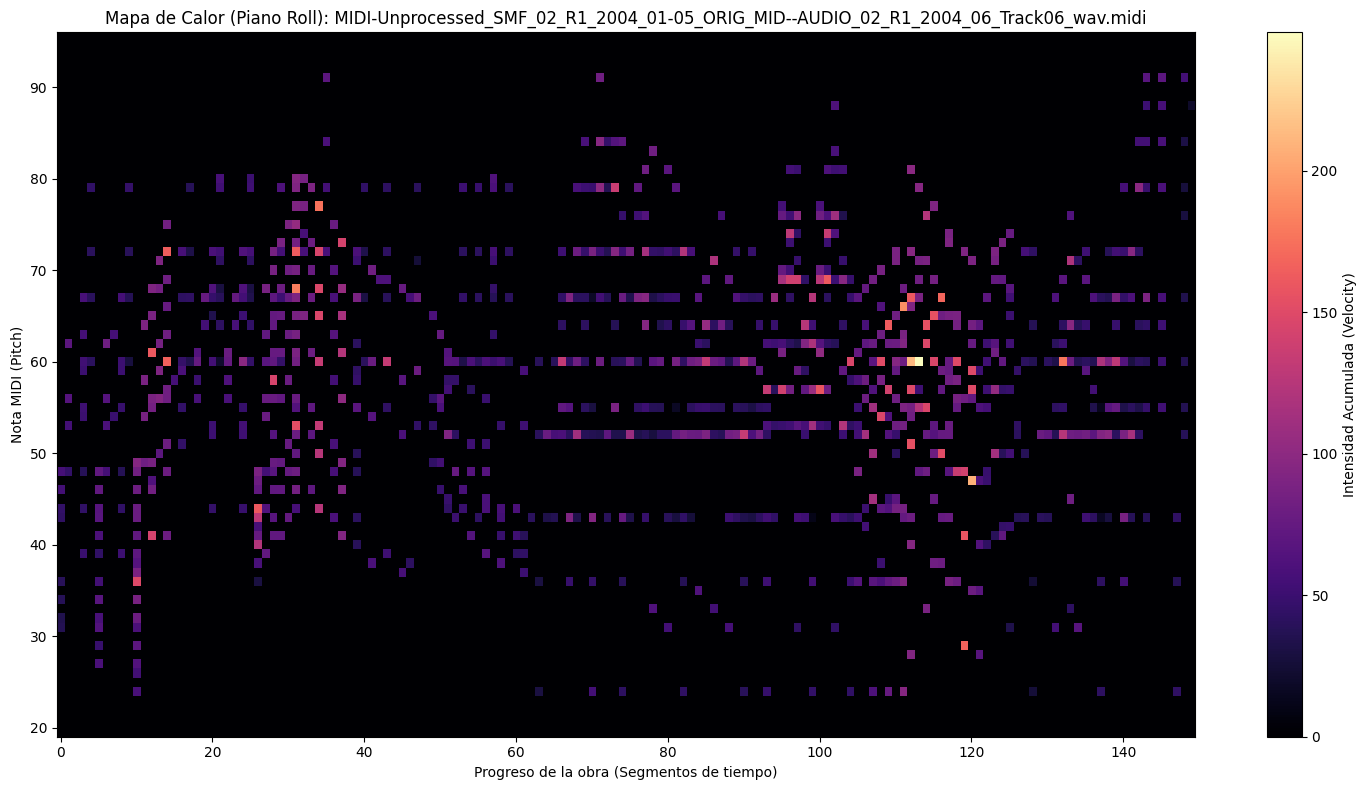

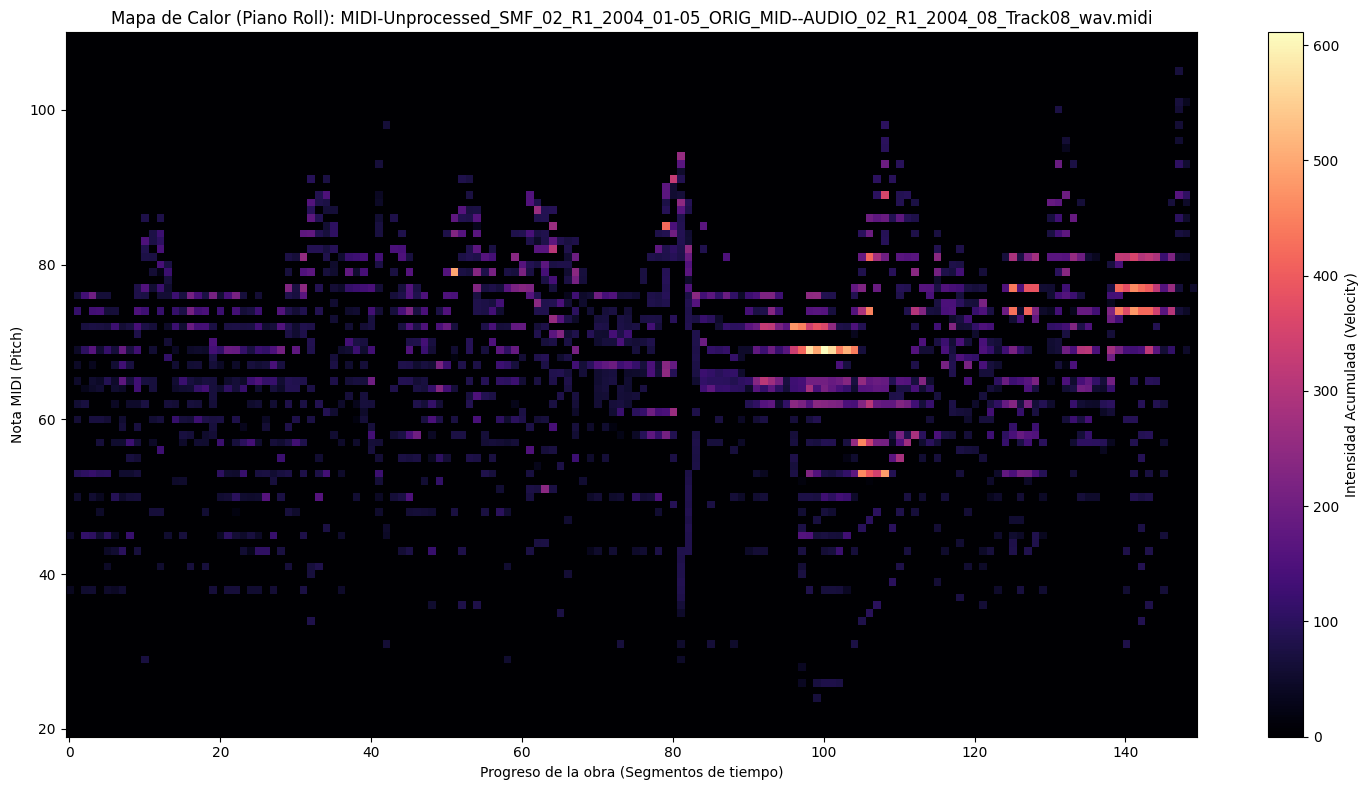

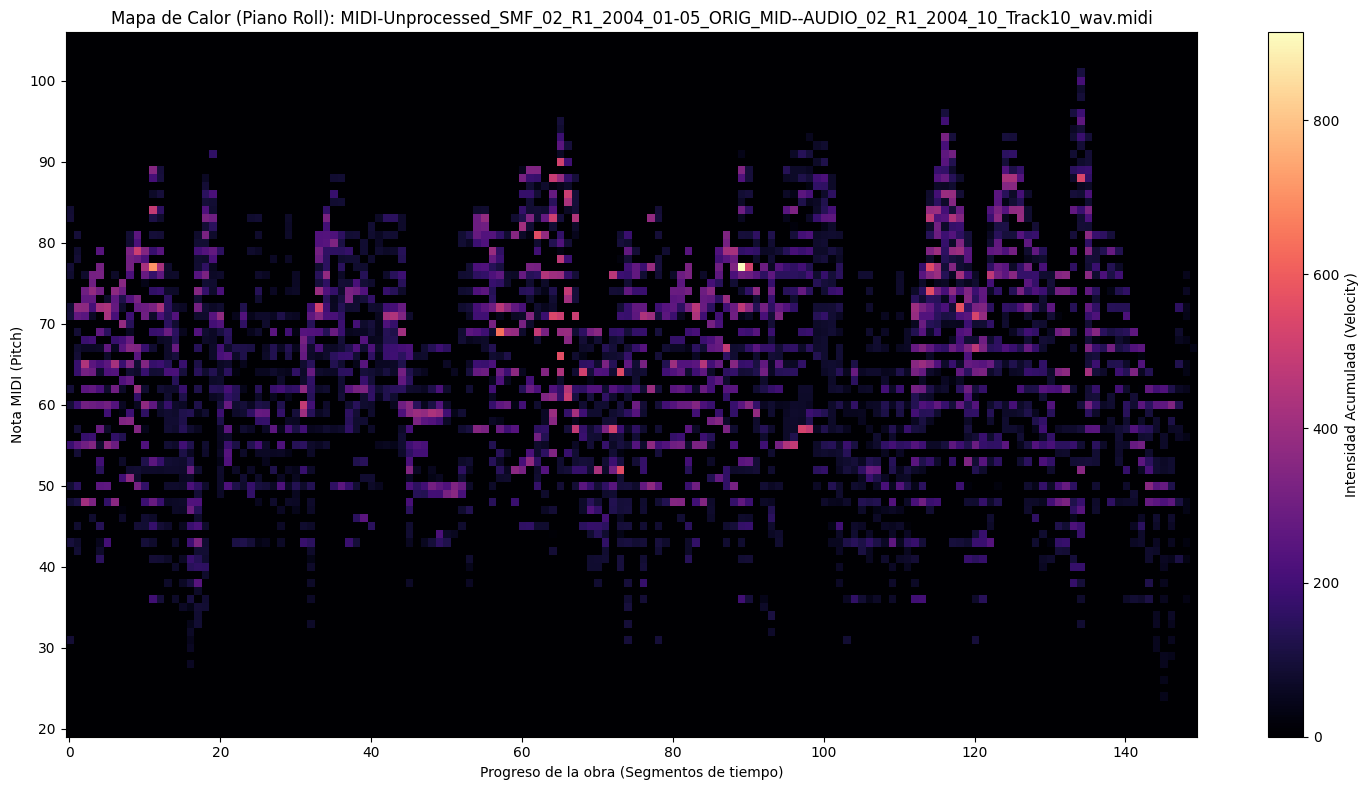

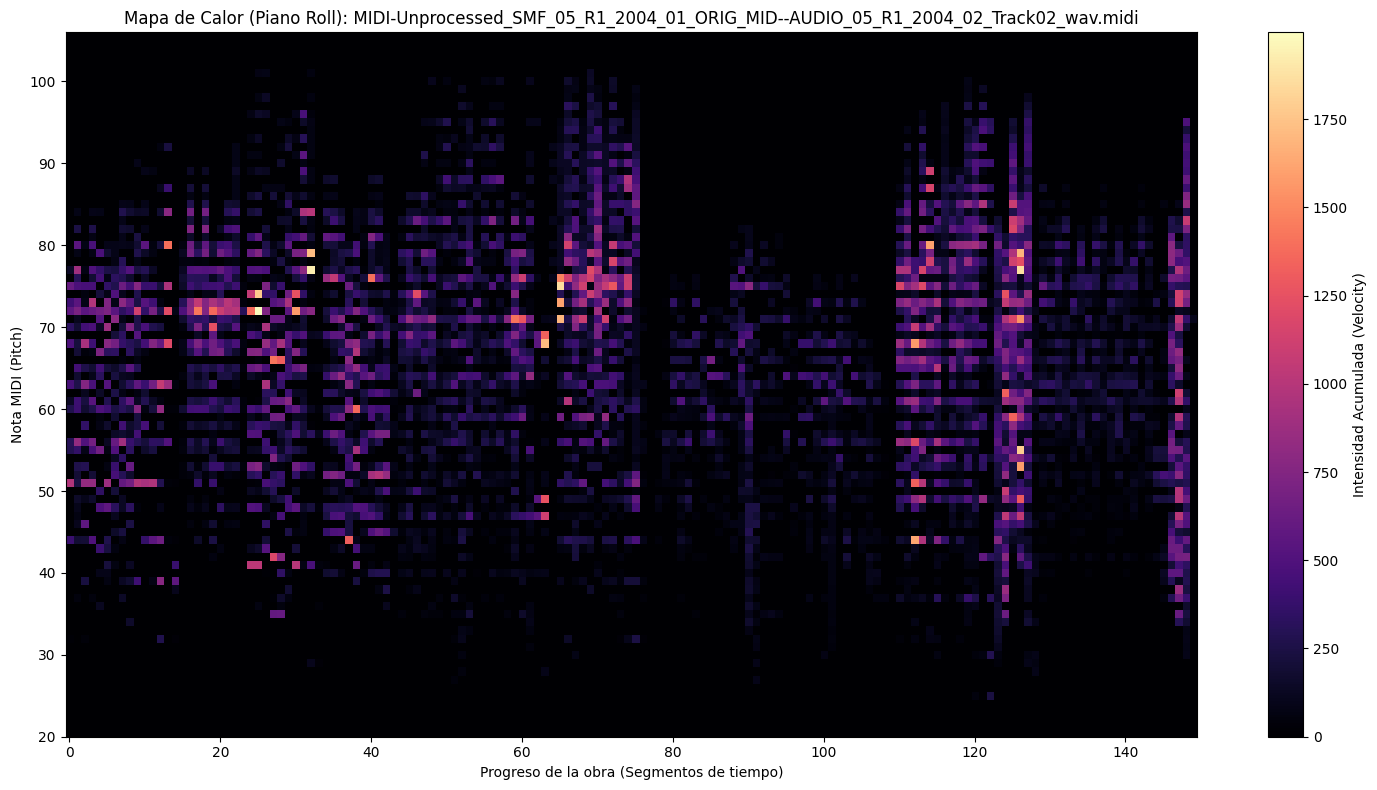

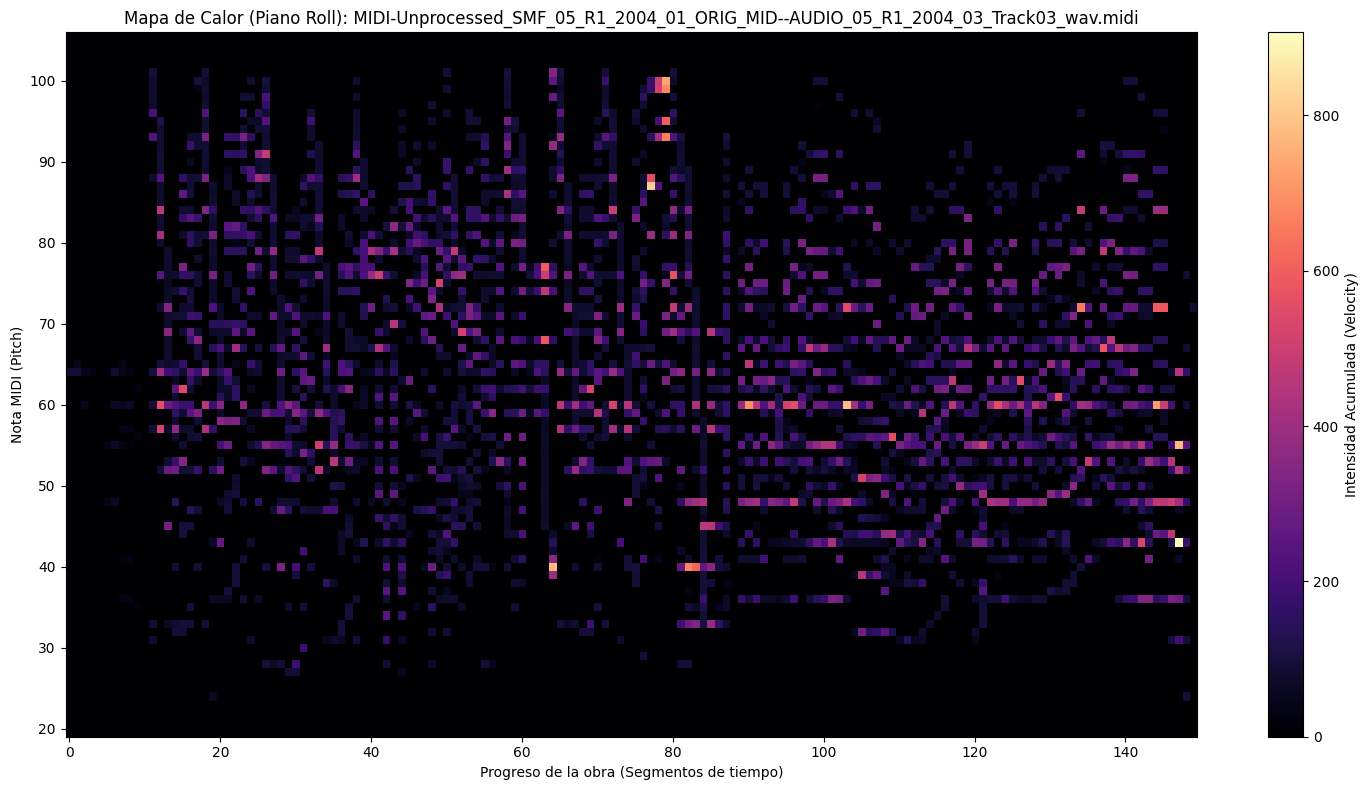

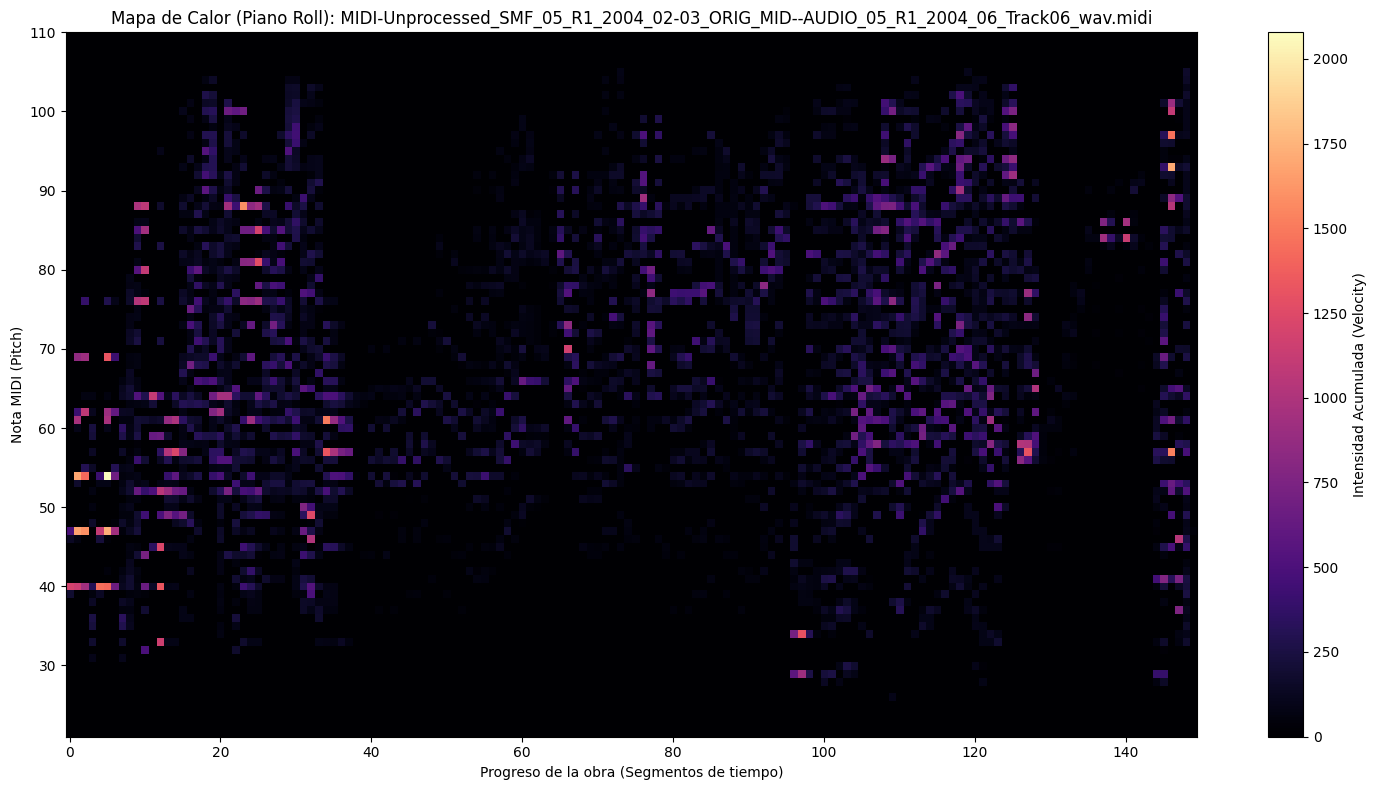

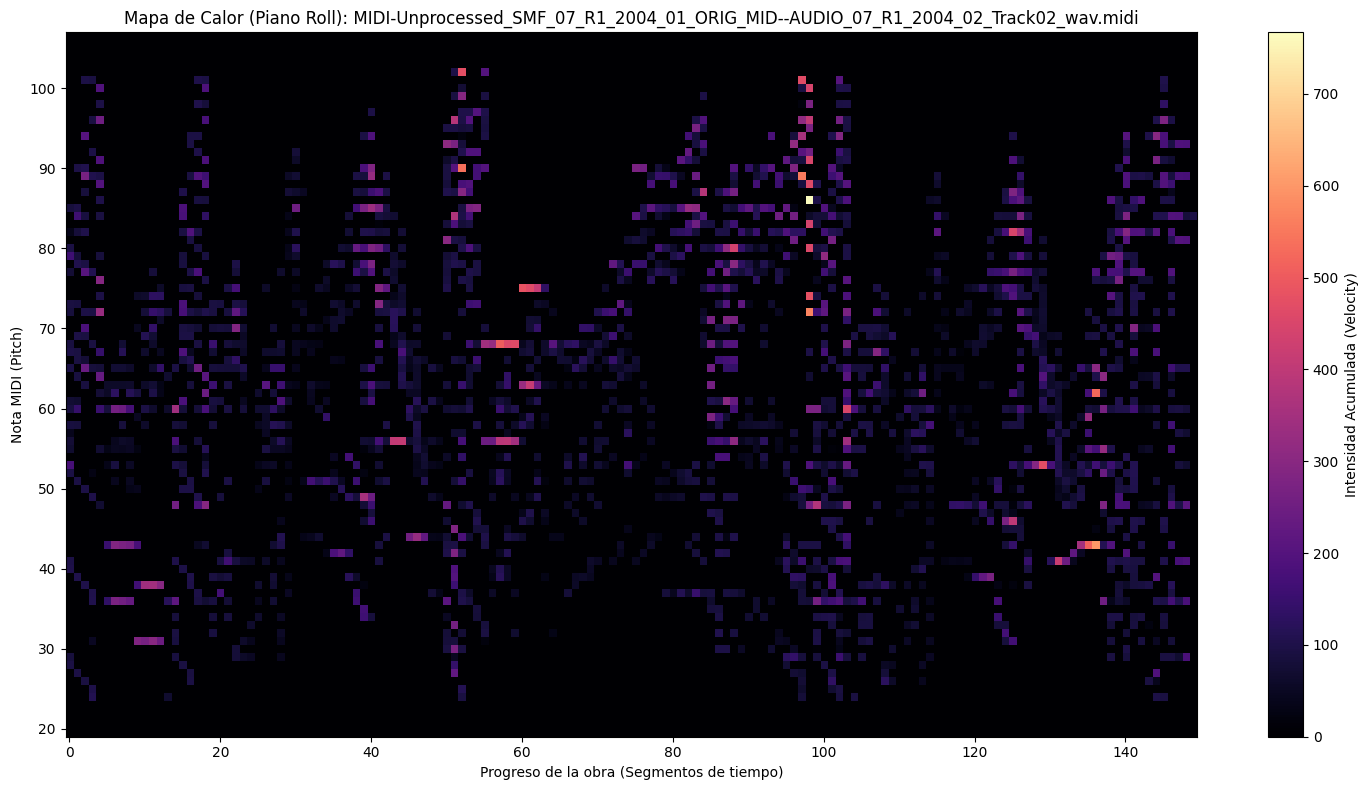

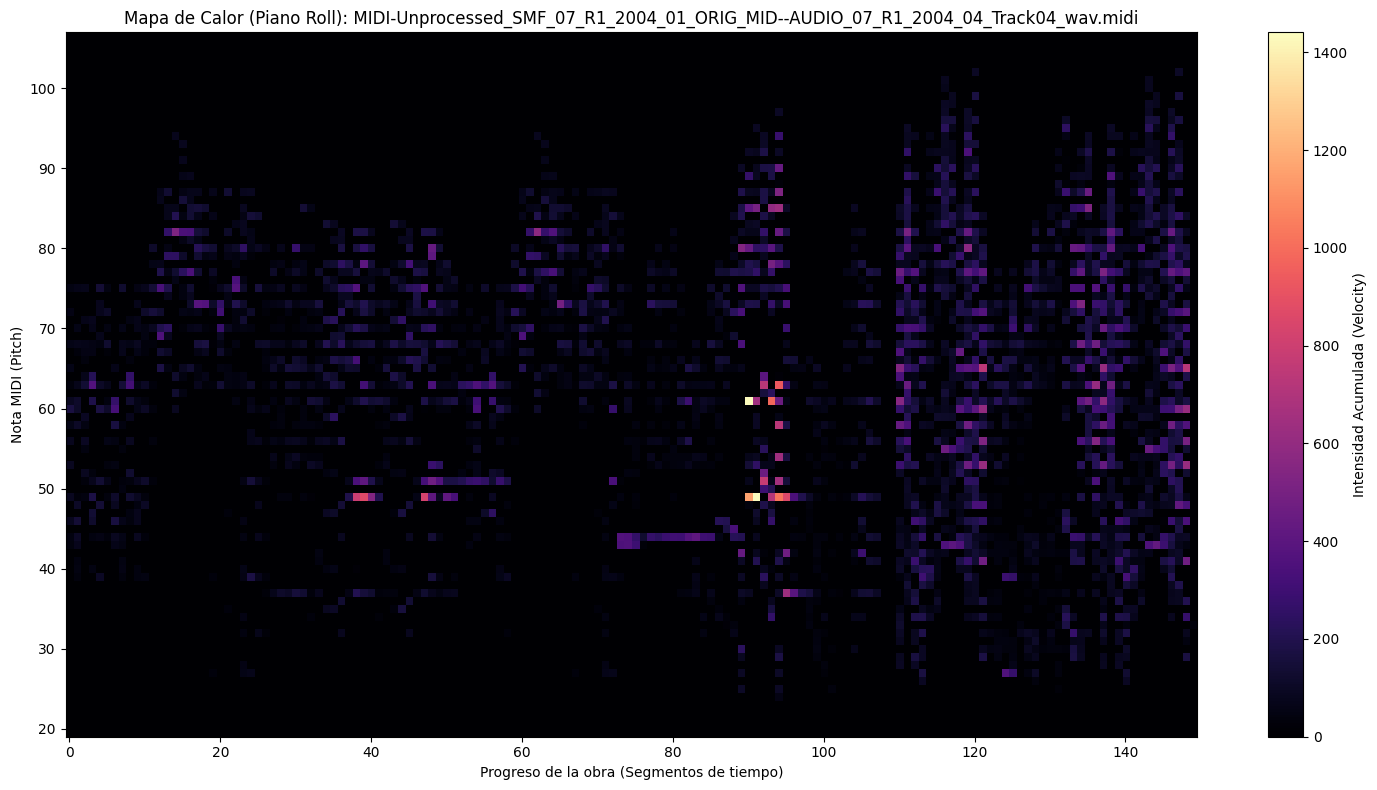

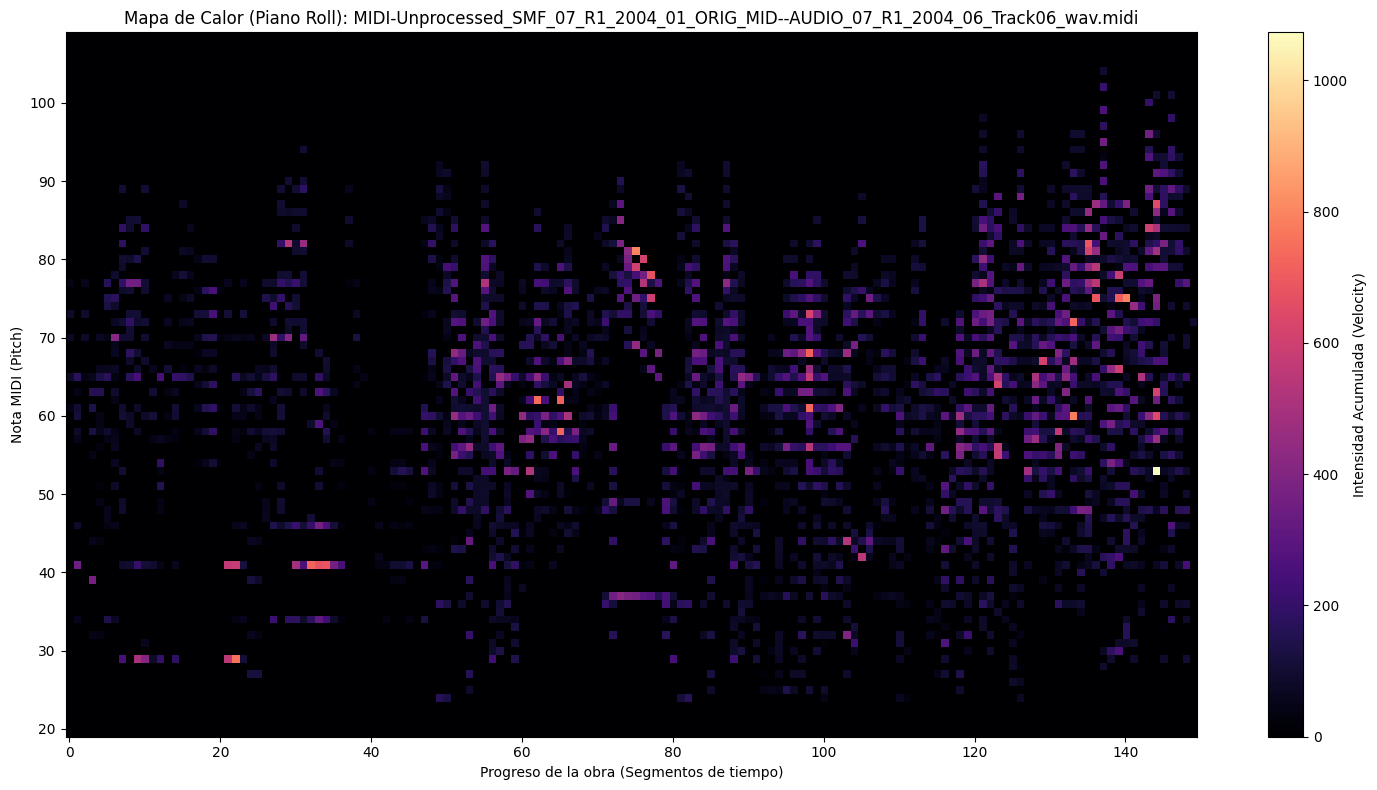

In [4]:
for i in range (1,10):
    visualizar_heatmap_midi(archivos[i], resolucion_pasos=150)